# LWCNN — External Evaluation Fix

Loads the saved LWCNN model and re-runs external Svanström evaluation
with the corrected clip-level probability aggregation (clamped before calibration).

In [1]:
!pip -q install librosa numpy scikit-learn tensorflow pandas scipy matplotlib

In [2]:
import os, glob, zipfile, requests, time
import numpy as np
import pandas as pd
import librosa
import scipy.optimize
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from google.colab import drive
drive.mount('/content/drive')

SEED       = 42
rng        = np.random.default_rng(SEED)
WIN_S      = 0.5
HOP_S      = 0.25
SR_TARGET  = 16000
sr_used    = SR_TARGET
N_MELS     = 64
N_FFT      = 512
HOP_LENGTH = 128
FMAX       = 8000
TOP_DB     = 80
AUG_PROB   = 0.7
SNR_MIN    = -5.0
SNR_MAX    = 20.0
BATCH      = 64
THRESHOLDS = np.round(np.arange(0.05, 0.96, 0.05), 2)

OUT_DIR    = '/content/drive/MyDrive/drone_audio_processed'
FIG_DIR    = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
MODEL_PATH = os.path.join(OUT_DIR, 'model_lwcnn_drone_binary.keras')
NPZ_PATH   = os.path.join(OUT_DIR, 'waveform_0.50s_hop0.25s_recordsplit.npz')

DEMAND_DIR         = '/content/DEMAND'
DEMAND_ZENODO_BASE = 'https://zenodo.org/records/1227121/files'
DEMAND_16K_ENVS    = ['DKITCHEN','DLIVING','DWASHING','NFIELD','NPARK','NRIVER',
                       'OHALLWAY','OMEETING','OOFFICE','PCAFETER','PRESTO','PSTATION',
                       'SPSQUARE','STRAFFIC','TBUS','TCAR','TMETRO']
EXT_ROOT   = '/content/external_drone_thesis'
EXT_ZIP_URL = 'https://codeload.github.com/DroneDetectionThesis/Drone-detection-dataset/zip/refs/heads/master'

CMAP = LinearSegmentedColormap.from_list('thesis_blue', ['#FFFFFF','#2E74B5'], N=256)
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10})
print('Config loaded. TF:', tf.__version__)

Mounted at /content/drive
Config loaded. TF: 2.20.0


In [3]:
# Helpers
def log_mel_db(y, sr=SR_TARGET):
    mel = librosa.feature.melspectrogram(y=y.astype(np.float32), sr=sr,
            n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=FMAX, power=2.0)
    return librosa.power_to_db(mel, ref=1.0, top_db=TOP_DB).astype(np.float32)

def windows_all(y, sr, win_s, hop_s, rng_local):
    y = np.asarray(y, dtype=np.float32)
    win = int(round(win_s*sr)); hop = int(round(hop_s*sr))
    if len(y) <= win:
        out = np.zeros(win, dtype=np.float32)
        s = rng_local.integers(0, win-len(y)+1); out[s:s+len(y)] = y; return [out]
    return [y[s:s+win] for s in range(0, len(y)-win+1, hop)]

def mel_to_model_array(mel):
    mel = mel[...,None].astype(np.float32)
    return ((mel-np.mean(mel))/(np.std(mel)+1e-6)).astype(np.float32)

def rms(x): return np.sqrt(np.mean(np.asarray(x,dtype=np.float32)**2)+1e-12)

def add_real_noise_snr(y, noise_bank, snr_db, rng_local):
    y = np.asarray(y, dtype=np.float32)
    nb = noise_bank[rng_local.integers(0,len(noise_bank))]
    n = len(y)
    if len(nb)>=n: s=rng_local.integers(0,len(nb)-n+1); nb=nb[s:s+n]
    else: nb=np.tile(nb,int(np.ceil(n/len(nb))))[:n]
    noise_scaled = nb*(rms(y)/(10**(snr_db/20.0))/(rms(nb)+1e-12))
    y_noisy=y+noise_scaled; peak=np.max(np.abs(y_noisy))
    return (y_noisy/peak).astype(np.float32) if peak>1.0 else y_noisy

def drone_metrics(y_true, y_prob, t):
    pred=(y_prob>=t).astype(int)
    cm=confusion_matrix(y_true,pred,labels=[0,1])
    tp=cm[1,1];fp=cm[0,1];fn=cm[1,0]
    prec=tp/(tp+fp+1e-9);rec=tp/(tp+fn+1e-9)
    return prec,rec,2*prec*rec/(prec+rec+1e-9)

def plot_cm(cm, title, ax):
    thresh=cm.max()/2.0
    im=ax.imshow(cm,cmap=CMAP,vmin=0,vmax=cm.max(),interpolation='nearest')
    plt.colorbar(im,ax=ax,fraction=0.046,pad=0.06).set_label('Count',fontsize=8)
    ax.set_xticks([0,1]);ax.set_yticks([0,1])
    ax.set_xticklabels(['No Drone','Drone'],fontsize=9)
    ax.set_yticklabels(['No Drone','Drone'],fontsize=9)
    ax.set_xlabel('Predicted',fontsize=9,labelpad=8)
    ax.set_ylabel('Actual',fontsize=9,labelpad=18)
    ax.set_title(title,fontsize=9,fontweight='normal',pad=10)
    for row in range(2):
        rt=cm[row].sum()
        for col in range(2):
            count=cm[row,col];pct=count/rt*100 if rt>0 else 0
            color='white' if count>thresh else '#1a1a1a'
            ax.text(col,row-0.12,[['TN','FP'],['FN','TP']][row][col],
                    ha='center',va='center',fontsize=11,fontweight='bold',color=color)
            ax.text(col,row+0.12,f'{count:,}\n({pct:.1f}%)',
                    ha='center',va='center',fontsize=9,color=color)

def save_fig(fig, name):
    path=os.path.join(FIG_DIR,name)
    fig.savefig(path,dpi=200,bbox_inches='tight',facecolor='white')
    print(f'Saved: {path}')

print('Helpers defined.')

Helpers defined.


In [4]:
# Load DEMAND noise bank
if not os.path.exists(DEMAND_DIR) or not glob.glob(os.path.join(DEMAND_DIR,'**','*.wav'),recursive=True):
    os.makedirs(DEMAND_DIR,exist_ok=True)
    for env in DEMAND_16K_ENVS:
        url=f'{DEMAND_ZENODO_BASE}/{env}_16k.zip?download=1'
        zip_path=f'/content/demand_{env.lower()}.zip'
        print(f'  {env}...',end=' ',flush=True)
        for attempt in range(3):
            try: r=requests.get(url,stream=True,timeout=120);r.raise_for_status();break
            except: time.sleep(5)
        with open(zip_path,'wb') as f:
            for chunk in r.iter_content(1024*1024): f.write(chunk)
        with zipfile.ZipFile(zip_path) as z: z.extractall(DEMAND_DIR)
        os.remove(zip_path);print('done')

noise_bank=[];seg_n=int(3.0*sr_used)
for p in glob.glob(os.path.join(DEMAND_DIR,'**','*.wav'),recursive=True):
    try:
        y,fs=librosa.load(p,sr=None,mono=True)
        if fs!=sr_used: y=librosa.resample(y,orig_sr=fs,target_sr=sr_used)
        for s in range(0,len(y)-seg_n+1,seg_n):
            seg=y[s:s+seg_n].astype(np.float32)
            if np.max(np.abs(seg))>1e-4: noise_bank.append(seg)
    except: pass
print(f'Noise bank: {len(noise_bank)} segments')

  DKITCHEN... done
  DLIVING... done
  DWASHING... done
  NFIELD... done
  NPARK... done
  NRIVER... done
  OHALLWAY... done
  OMEETING... done
  OOFFICE... done
  PCAFETER... done
  PRESTO... done
  PSTATION... done
  SPSQUARE... done
  STRAFFIC... done
  TBUS... done
  TCAR... done
  TMETRO... done
Noise bank: 27200 segments


In [8]:
# Load LWCNN model
print(f'Loading model: {MODEL_PATH}')
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/drone_audio_processed/model_lwcnn_drone_binary.keras',
    compile=False, safe_mode=False)
print(f'Parameters: {model.count_params():,}')

Loading model: /content/drive/MyDrive/drone_audio_processed/model_lwcnn_drone_binary.keras
Parameters: 59,649


In [9]:
# Load internal test set and fit temperature scaling
print(f'Loading NPZ: {NPZ_PATH}')
npz = np.load(NPZ_PATH, allow_pickle=True)
X_test_wav = npz['X_test_wav'].astype(np.float32)
y_test     = npz['y_test_wav'].astype(int)
X_val_wav  = npz['X_val_wav'].astype(np.float32)
y_val      = npz['y_val_wav'].astype(int)
print(f'Test: {X_test_wav.shape} | Val: {X_val_wav.shape}')

# Compute test mels and get logits
print('Computing internal test mels...')
X_test_mel = []
for i,w in enumerate(X_test_wav):
    if i%10000==0: print(f'  {i}/{len(X_test_wav)}')
    lr=np.random.default_rng(SEED+i)
    if lr.random()<AUG_PROB: w=add_real_noise_snr(w,noise_bank,lr.uniform(SNR_MIN,SNR_MAX),lr)
    X_test_mel.append(mel_to_model_array(log_mel_db(w)))
X_test = np.stack(X_test_mel).astype(np.float32)

print('Running internal predictions...')
int_logits = model.predict(X_test, batch_size=BATCH, verbose=1).ravel()
int_probs  = tf.sigmoid(int_logits).numpy()
int_auc    = roc_auc_score(y_test, int_probs)
print(f'Internal AUC: {int_auc:.4f}')

# Fit temperature on validation set
print('Computing val mels for temperature scaling...')
X_val_mel = []
for i,w in enumerate(X_val_wav):
    lr=np.random.default_rng(SEED+i+99999)
    if lr.random()<AUG_PROB: w=add_real_noise_snr(w,noise_bank,lr.uniform(SNR_MIN,SNR_MAX),lr)
    X_val_mel.append(mel_to_model_array(log_mel_db(w)))
X_val = np.stack(X_val_mel).astype(np.float32)
val_logits = model.predict(X_val, batch_size=BATCH, verbose=0).ravel()

def nll_loss(log_T):
    T=np.exp(log_T[0]);probs=1/(1+np.exp(-val_logits/T));eps=1e-7
    return -np.mean(y_val*np.log(probs+eps)+(1-y_val)*np.log(1-probs+eps))

result=scipy.optimize.minimize(nll_loss,x0=[0.0],method='L-BFGS-B')
TEMPERATURE=float(np.exp(result.x[0]))
print(f'Temperature T = {TEMPERATURE:.4f}')
int_probs_cal=tf.sigmoid(int_logits/TEMPERATURE).numpy()
print(f'Internal AUC (cal): {roc_auc_score(y_test,int_probs_cal):.4f}')

Loading NPZ: /content/drive/MyDrive/drone_audio_processed/waveform_0.50s_hop0.25s_recordsplit.npz
Test: (32694, 8000) | Val: (32731, 8000)
Computing internal test mels...
  0/32694
  10000/32694
  20000/32694
  30000/32694
Running internal predictions...
511/511 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step
Internal AUC: 0.9979
Computing val mels for temperature scaling...
Temperature T = 0.9007
Internal AUC (cal): 0.9979


In [10]:
# External Svanstrom evaluation — with fixed clamped calibration
os.makedirs(EXT_ROOT,exist_ok=True)
EXT_ZIP_PATH=os.path.join(EXT_ROOT,'repo.zip')
EXT_EXTRACT_DIR=os.path.join(EXT_ROOT,'repo')
if not os.path.exists(EXT_ZIP_PATH):
    print('Downloading Svanström...')
    r=requests.get(EXT_ZIP_URL,stream=True);r.raise_for_status()
    with open(EXT_ZIP_PATH,'wb') as f:
        for chunk in r.iter_content(1024*1024): f.write(chunk)
    with zipfile.ZipFile(EXT_ZIP_PATH) as z: z.extractall(EXT_EXTRACT_DIR)

subdirs=[p for p in glob.glob(os.path.join(EXT_EXTRACT_DIR,'*')) if os.path.isdir(p)]
ext_wavs=sorted(glob.glob(os.path.join(subdirs[0],'**','*.wav'),recursive=True))
ext_labels=np.array([1 if 'drone' in os.path.basename(p).lower() else 0 for p in ext_wavs])
print(f'External: {len(ext_wavs)} clips — drone:{ext_labels.sum()}, no-drone:{(ext_labels==0).sum()}')

local_rng=np.random.default_rng(SEED)
ext_clip_probs_uncal=[]
for p in ext_wavs:
    y,sr=librosa.load(p,sr=None,mono=True)
    if sr!=sr_used: y=librosa.resample(y,orig_sr=sr,target_sr=sr_used)
    wins=windows_all(y,sr_used,WIN_S,HOP_S,local_rng);X=[]
    for w in wins:
        if local_rng.random()<AUG_PROB:
            w=add_real_noise_snr(w,noise_bank,local_rng.uniform(SNR_MIN,SNR_MAX),local_rng)
        X.append(mel_to_model_array(log_mel_db(w)))
    if not X: ext_clip_probs_uncal.append(0.0);continue
    logits=model.predict(np.stack(X),batch_size=BATCH,verbose=0).ravel()
    probs=tf.sigmoid(logits).numpy()
    ext_clip_probs_uncal.append(float(np.max(probs)))  # max-pool

ext_clip_probs_uncal=np.array(ext_clip_probs_uncal)

# FIX: clamp before converting back to logits
eps=1e-6
probs_clamped=np.clip(ext_clip_probs_uncal,eps,1-eps)
ext_clip_logits=np.log(probs_clamped/(1-probs_clamped))
ext_clip_probs_cal=tf.sigmoid(ext_clip_logits/TEMPERATURE).numpy()

ext_auc_uncal=roc_auc_score(ext_labels,ext_clip_probs_uncal)
ext_auc_cal=roc_auc_score(ext_labels,ext_clip_probs_cal)
print(f'External clip AUC (uncal): {ext_auc_uncal:.4f}')
print(f'External clip AUC (cal):   {ext_auc_cal:.4f}')

for t_thresh,probs,label in [
    (0.5,ext_clip_probs_uncal,'UNCAL t=0.5'),
    (0.3,ext_clip_probs_uncal,'UNCAL t=0.3'),
    (0.5,ext_clip_probs_cal,'CAL   t=0.5'),
    (0.3,ext_clip_probs_cal,'CAL   t=0.3')]:
    pred=(probs>=t_thresh).astype(int)
    print(f'\n=== EXTERNAL ({label}) ===')
    print(confusion_matrix(ext_labels,pred))
    print(classification_report(ext_labels,pred,digits=4))

External: 90 clips — drone:30, no-drone:60
External clip AUC (uncal): 0.5461
External clip AUC (cal):   0.5461

=== EXTERNAL (UNCAL t=0.5) ===
[[21 39]
 [ 8 22]]
              precision    recall  f1-score   support

           0     0.7241    0.3500    0.4719        60
           1     0.3607    0.7333    0.4835        30

    accuracy                         0.4778        90
   macro avg     0.5424    0.5417    0.4777        90
weighted avg     0.6030    0.4778    0.4758        90


=== EXTERNAL (UNCAL t=0.3) ===
[[ 9 51]
 [ 1 29]]
              precision    recall  f1-score   support

           0     0.9000    0.1500    0.2571        60
           1     0.3625    0.9667    0.5273        30

    accuracy                         0.4222        90
   macro avg     0.6312    0.5583    0.3922        90
weighted avg     0.7208    0.4222    0.3472        90


=== EXTERNAL (CAL   t=0.5) ===
[[21 39]
 [ 8 22]]
              precision    recall  f1-score   support

           0     0.7241    

In [11]:
# Window-level external AUC
local_rng=np.random.default_rng(SEED)
all_wl=[];all_yl=[]
for p,lab in zip(ext_wavs,ext_labels):
    y,sr=librosa.load(p,sr=None,mono=True)
    if sr!=sr_used: y=librosa.resample(y,orig_sr=sr,target_sr=sr_used)
    for w in windows_all(y,sr_used,WIN_S,HOP_S,local_rng):
        if local_rng.random()<AUG_PROB:
            w=add_real_noise_snr(w,noise_bank,local_rng.uniform(SNR_MIN,SNR_MAX),local_rng)
        X=mel_to_model_array(log_mel_db(w))[None]
        all_wl.append(float(model.predict(X,verbose=0).ravel()[0]))
        all_yl.append(lab)
win_probs=tf.sigmoid(np.array(all_wl)).numpy()
print(f'Window-level external AUC: {roc_auc_score(all_yl,win_probs):.4f} ({len(win_probs)} windows)')

Window-level external AUC: 0.5698 (3510 windows)


In [12]:
# Threshold sweep
def run_sweep(ip,ep,label):
    rows=[]
    for t in THRESHOLDS:
        _,_,if1=drone_metrics(y_test,ip,t)
        _,er,ef1=drone_metrics(ext_labels,ep,t)
        combined=2*if1*er/(if1+er+1e-9)
        rows.append(dict(threshold=t,int_f1=round(if1,4),ext_recall=round(er,4),
                         ext_f1=round(ef1,4),combined=round(combined,4)))
    df=pd.DataFrame(rows);best=df.loc[df['combined'].idxmax()]
    print(f'\n=== {label} ===');print(df.to_string(index=False))
    print(f'Optimal t={best["threshold"]}  combined={best["combined"]}  int_f1={best["int_f1"]}  ext_recall={best["ext_recall"]}')
    return df,best

df_uncal,best_uncal=run_sweep(int_probs,    ext_clip_probs_uncal,'UNCALIBRATED')
df_cal,  best_cal  =run_sweep(int_probs_cal,ext_clip_probs_cal,  f'CALIBRATED T={TEMPERATURE:.4f}')


=== UNCALIBRATED ===
 threshold  int_f1  ext_recall  ext_f1  combined
      0.05  0.9529      1.0000  0.5085    0.9759
      0.10  0.9712      1.0000  0.5128    0.9854
      0.15  0.9786      1.0000  0.5128    0.9892
      0.20  0.9829      0.9667  0.5179    0.9747
      0.25  0.9846      0.9667  0.5273    0.9756
      0.30  0.9861      0.9667  0.5273    0.9763
      0.35  0.9871      0.8667  0.5098    0.9230
      0.40  0.9877      0.8333  0.5051    0.9040
      0.45  0.9882      0.8000  0.4948    0.8842
      0.50  0.9883      0.7333  0.4835    0.8420
      0.55  0.9884      0.7333  0.4835    0.8420
      0.60  0.9887      0.7333  0.4889    0.8421
      0.65  0.9886      0.7000  0.4773    0.8196
      0.70  0.9885      0.6667  0.4706    0.7963
      0.75  0.9884      0.6000  0.4337    0.7467
      0.80  0.9879      0.6000  0.4500    0.7466
      0.85  0.9874      0.5667  0.4359    0.7201
      0.90  0.9867      0.4667  0.3889    0.6336
      0.95  0.9849      0.4333  0.4000    0.601

Saved: /content/drive/MyDrive/drone_audio_processed/figures/lwcnn_external_cm.png


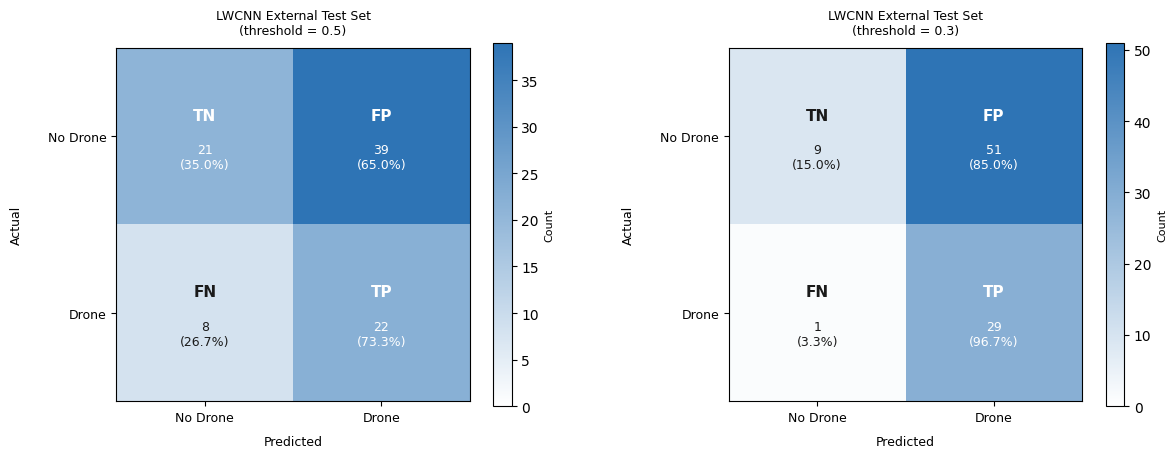

In [13]:
# External confusion matrices
fig,axes=plt.subplots(1,2,figsize=(13,5));fig.subplots_adjust(wspace=0.55)
plot_cm(confusion_matrix(ext_labels,(ext_clip_probs_uncal>=0.5).astype(int)),
        'LWCNN External Test Set\n(threshold = 0.5)',axes[0])
plot_cm(confusion_matrix(ext_labels,(ext_clip_probs_uncal>=0.3).astype(int)),
        'LWCNN External Test Set\n(threshold = 0.3)',axes[1])
save_fig(fig,'lwcnn_external_cm.png');plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/lwcnn_external_roc.png


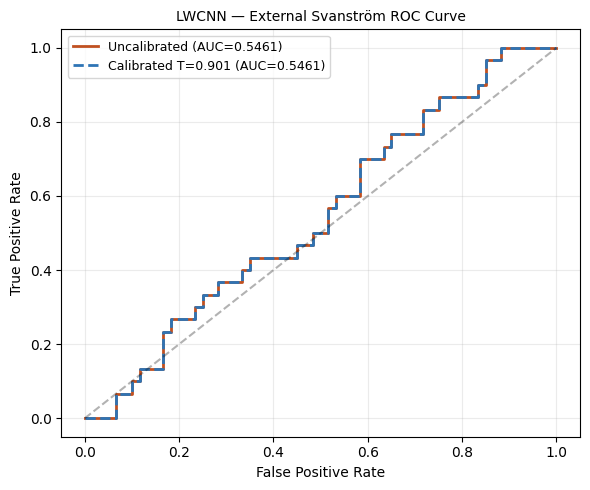

In [14]:
# External ROC
fig,ax=plt.subplots(figsize=(6,5))
fpr_u,tpr_u,_=roc_curve(ext_labels,ext_clip_probs_uncal)
fpr_c,tpr_c,_=roc_curve(ext_labels,ext_clip_probs_cal)
ax.plot(fpr_u,tpr_u,color='#C05020',lw=2,label=f'Uncalibrated (AUC={ext_auc_uncal:.4f})')
ax.plot(fpr_c,tpr_c,color='#2E74B5',lw=2,ls='--',label=f'Calibrated T={TEMPERATURE:.3f} (AUC={ext_auc_cal:.4f})')
ax.plot([0,1],[0,1],'k--',alpha=0.3)
ax.set_xlabel('False Positive Rate');ax.set_ylabel('True Positive Rate')
ax.set_title('LWCNN — External Svanström ROC Curve',fontsize=10,fontweight='normal')
ax.legend(fontsize=9);ax.grid(alpha=0.25);plt.tight_layout()
save_fig(fig,'lwcnn_external_roc.png');plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/lwcnn_threshold_sweep.png


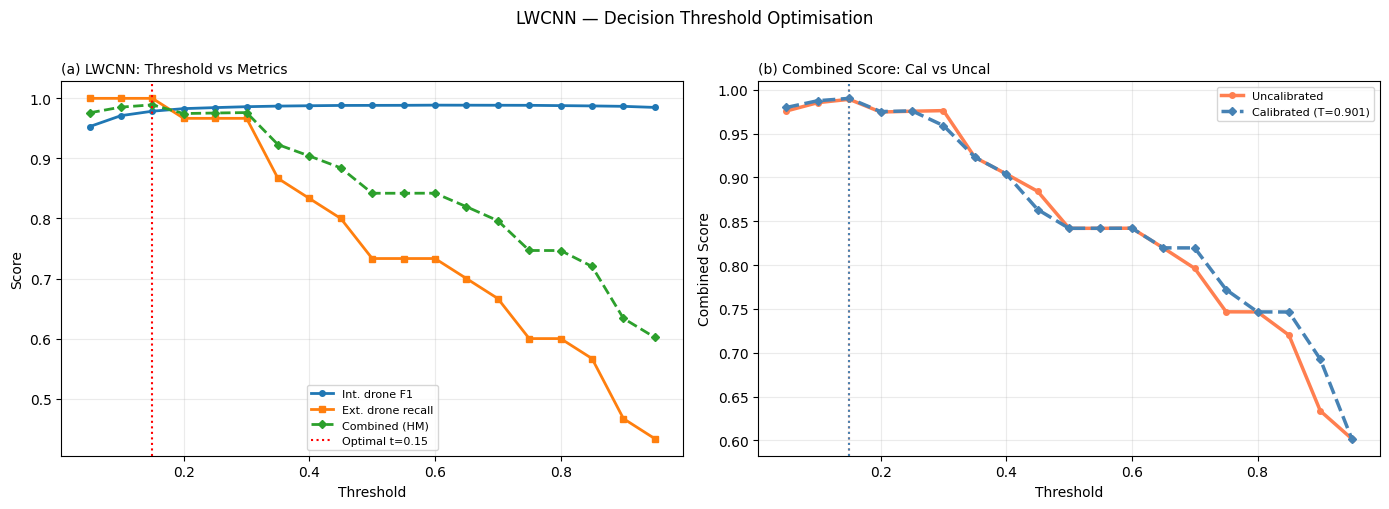

In [15]:
# Threshold sweep plot
fig,axes=plt.subplots(1,2,figsize=(14,5))
ax=axes[0]
ax.plot(df_uncal['threshold'],df_uncal['int_f1'],lw=2,marker='o',ms=4,label='Int. drone F1')
ax.plot(df_uncal['threshold'],df_uncal['ext_recall'],lw=2,marker='s',ms=4,label='Ext. drone recall')
ax.plot(df_uncal['threshold'],df_uncal['combined'],lw=2,ls='--',marker='D',ms=4,label='Combined (HM)')
ax.axvline(float(best_uncal['threshold']),color='red',ls=':',lw=1.5,label=f'Optimal t={best_uncal["threshold"]}')
ax.set_xlabel('Threshold');ax.set_ylabel('Score')
ax.set_title('(a) LWCNN: Threshold vs Metrics',fontsize=10,fontweight='normal',loc='left')
ax.legend(fontsize=8);ax.grid(alpha=0.25)
ax=axes[1]
ax.plot(df_uncal['threshold'],df_uncal['combined'],lw=2.5,color='coral',marker='o',ms=4,label='Uncalibrated')
ax.plot(df_cal['threshold'],df_cal['combined'],lw=2.5,color='steelblue',marker='D',ms=4,ls='--',
        label=f'Calibrated (T={TEMPERATURE:.3f})')
ax.axvline(float(best_uncal['threshold']),color='coral',ls=':',lw=1.5)
ax.axvline(float(best_cal['threshold']),color='steelblue',ls=':',lw=1.5)
ax.set_xlabel('Threshold');ax.set_ylabel('Combined Score')
ax.set_title('(b) Combined Score: Cal vs Uncal',fontsize=10,fontweight='normal',loc='left')
ax.legend(fontsize=8);ax.grid(alpha=0.25)
fig.suptitle('LWCNN — Decision Threshold Optimisation',fontsize=12,y=1.01);plt.tight_layout()
save_fig(fig,'lwcnn_threshold_sweep.png');plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/lwcnn_temperature_scaling.png


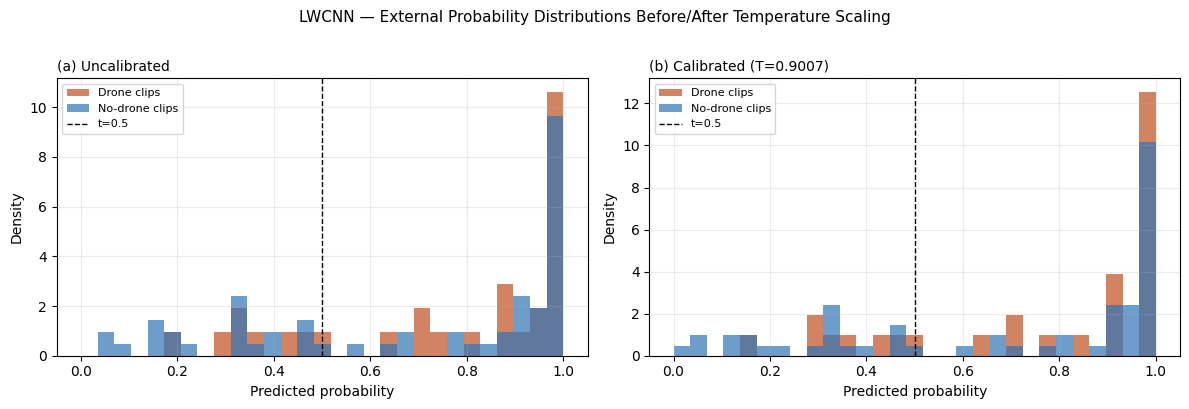

In [16]:
# Temperature scaling distributions
fig,axes=plt.subplots(1,2,figsize=(12,4))
bins=np.linspace(0,1,30);dm=ext_labels==1;ndm=ext_labels==0
for ax,probs,title in [
    (axes[0],ext_clip_probs_uncal,'(a) Uncalibrated'),
    (axes[1],ext_clip_probs_cal,f'(b) Calibrated (T={TEMPERATURE:.4f})')]:
    ax.hist(probs[dm],bins=bins,alpha=0.7,color='#C05020',label='Drone clips',density=True)
    ax.hist(probs[ndm],bins=bins,alpha=0.7,color='#2E74B5',label='No-drone clips',density=True)
    ax.axvline(0.5,color='black',ls='--',lw=1,label='t=0.5')
    ax.set_xlabel('Predicted probability');ax.set_ylabel('Density')
    ax.set_title(title,fontsize=10,fontweight='normal',loc='left')
    ax.legend(fontsize=8);ax.grid(alpha=0.25)
fig.suptitle('LWCNN — External Probability Distributions Before/After Temperature Scaling',
             fontsize=11,y=1.01)
plt.tight_layout();save_fig(fig,'lwcnn_temperature_scaling.png');plt.show()

In [17]:
# Final summary
print('\n'+'='*60)
print('LWCNN — EXTERNAL EVALUATION SUMMARY (FIXED)')
print('='*60)
print(f'Temperature T        : {TEMPERATURE:.4f}')
print(f'Internal AUC (uncal) : {int_auc:.4f}')
print(f'Internal AUC (cal)   : {roc_auc_score(y_test,int_probs_cal):.4f}')
print(f'External AUC (uncal) : {ext_auc_uncal:.4f}')
print(f'External AUC (cal)   : {ext_auc_cal:.4f}')
print()
print(f'Optimal t (uncal)    : {best_uncal["threshold"]}  combined: {best_uncal["combined"]}')
print(f'Optimal t (cal)      : {best_cal["threshold"]}  combined: {best_cal["combined"]}')
print(f'\nFigures saved to: {FIG_DIR}')


LWCNN — EXTERNAL EVALUATION SUMMARY (FIXED)
Temperature T        : 0.9007
Internal AUC (uncal) : 0.9979
Internal AUC (cal)   : 0.9979
External AUC (uncal) : 0.5461
External AUC (cal)   : 0.5461

Optimal t (uncal)    : 0.15  combined: 0.9892
Optimal t (cal)      : 0.15  combined: 0.9903

Figures saved to: /content/drive/MyDrive/drone_audio_processed/figures
